# Data Inspection - AI4I 2020 Predictive Maintenance Dataset

**Name:** Daimi Syed Shais  
**Branch:** dev/shais  
**Task:** Inspect the dataset before preprocessing and modelling

**Dataset:** AI4I 2020 Predictive Maintenance (UCI ML Repository)  
**Goal:** Predict machine failure using a Decision Tree Classifier


### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# to handle input file(s)
from pathlib import Path

### 2. Load Dataset

In [2]:
# csv file path (to resolve problem at production level)
BASE_DIR = Path().resolve().parent
df = pd.read_csv(BASE_DIR / 'Dataset' / 'ai4i2020.csv')
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (10000, 14)


### 3. First Look

In [3]:
print("First 5 rows:\n")
df.head()

First 5 rows:



,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
print("Column names and data types:\n")
print(df.dtypes)

Column names and data types:

UDI                          int64
Product ID                     str
Type                           str
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object


### 4. Basic Statistics

In [5]:
print("Statistical Summary:\n")
df.describe()

Statistical Summary:



,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### 5. Missing Values

In [6]:
print("Missing values per column:\n")
print(df.isnull().sum())
print()
print("Total missing values:", df.isnull().sum().sum())

Missing values per column:

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Total missing values: 0


### 6. Duplicate Rows

In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


### 7. Target Variable - Class Distribution

In [8]:
print("Machine Failure - Value Counts:\n")
print(df['Machine failure'].value_counts())
print()
print("Class imbalance ratio:", round(
    df['Machine failure'].value_counts()[0] / df['Machine failure'].value_counts()[1], 1
), ": 1")

Machine Failure - Value Counts:

Machine failure
0    9661
1     339
Name: count, dtype: int64

Class imbalance ratio: 28.5 : 1


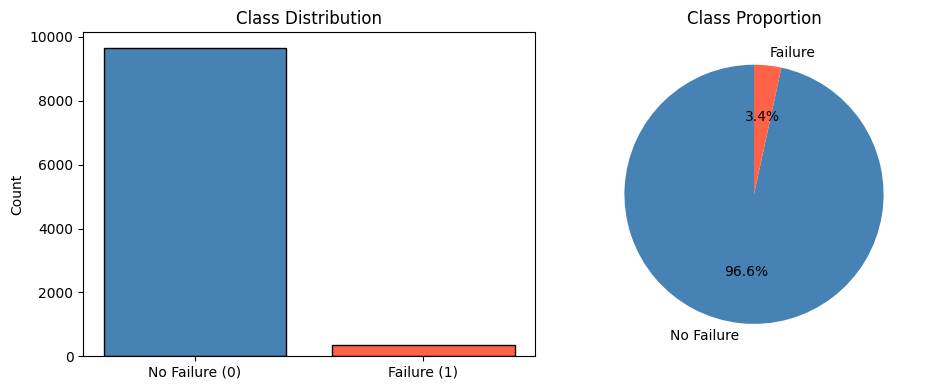

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

counts = df['Machine failure'].value_counts()

axes[0].bar(['No Failure (0)', 'Failure (1)'], counts.values,
            color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

axes[1].pie(counts.values, labels=['No Failure', 'Failure'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

### 8. Feature Distributions

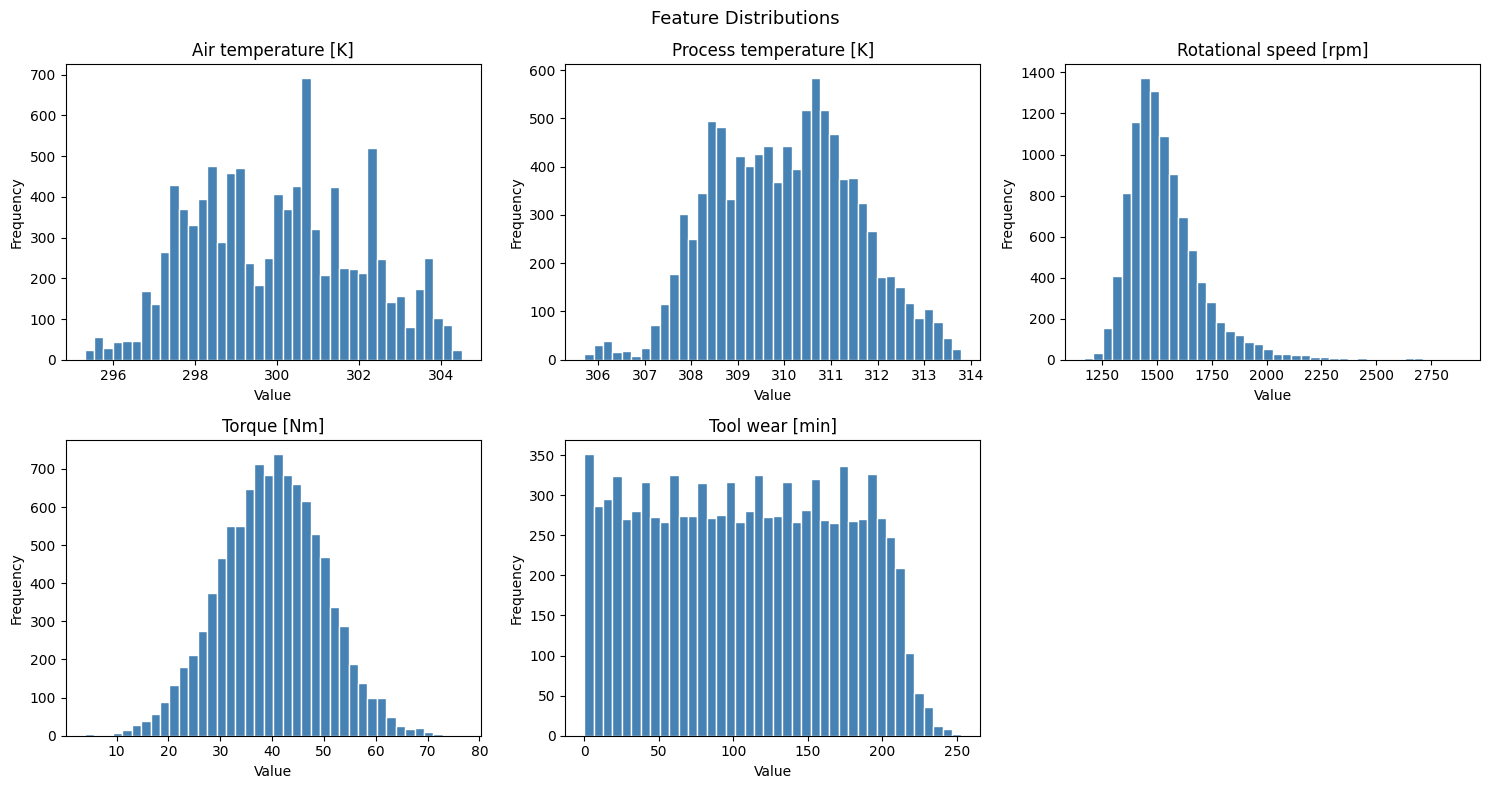

In [10]:
num_features = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_features):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[5].axis('off')
plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

Product Type Distribution:

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


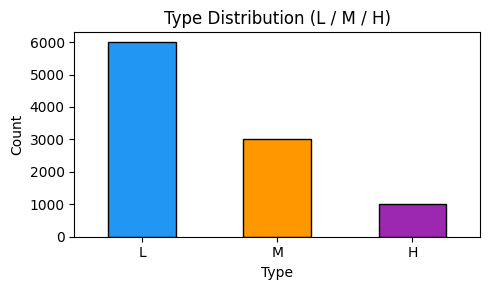

In [11]:
print("Product Type Distribution:\n")
print(df['Type'].value_counts())

df['Type'].value_counts().plot(kind='bar', color=['#2196F3','#FF9800','#9C27B0'],
                                edgecolor='black', figsize=(5,3))
plt.title('Type Distribution (L / M / H)')
plt.xlabel('Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 9. Outlier Check (IQR Method)

In [12]:
print("Outliers per feature (IQR method):\n")
for col in num_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

Outliers per feature (IQR method):

Air temperature [K]: 0 outliers
Process temperature [K]: 0 outliers
Rotational speed [rpm]: 418 outliers
Torque [Nm]: 69 outliers
Tool wear [min]: 0 outliers


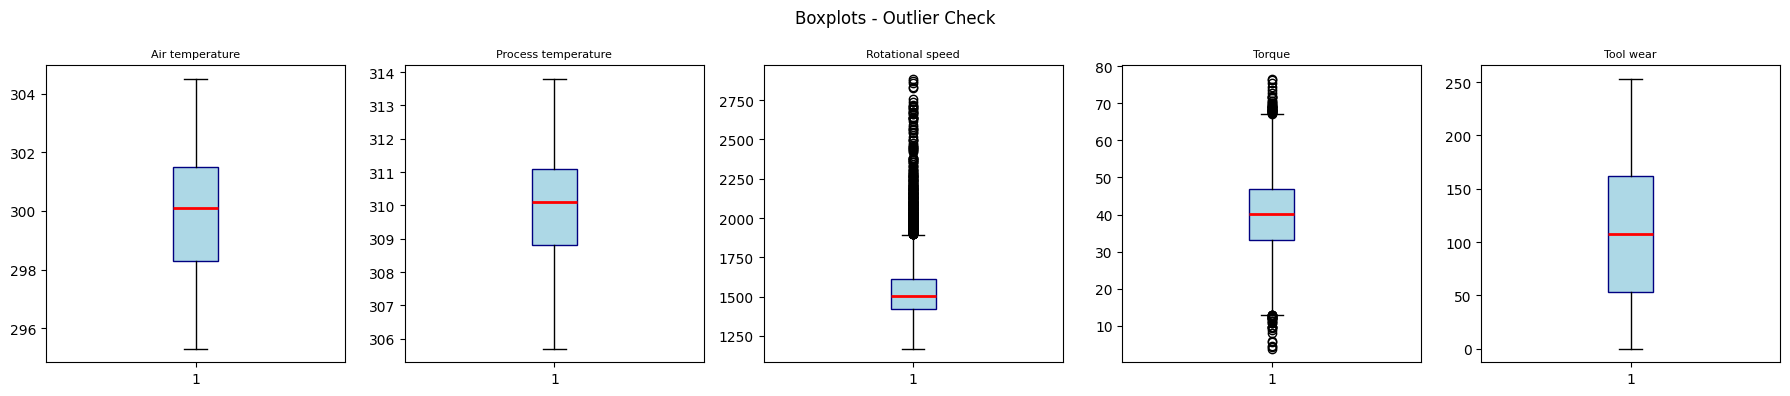

In [13]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(num_features):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='navy'),
                    medianprops=dict(color='red', linewidth=2))
    axes[i].set_title(col.split(' [')[0], fontsize=8)

plt.suptitle('Boxplots - Outlier Check')
plt.tight_layout()
plt.show()

### 10. Failure Type Breakdown

In [14]:
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
print("Failure type counts:\n")
for col in failure_cols:
    print(f"{col}: {df[col].sum()}")

Failure type counts:

TWF: 46
HDF: 115
PWF: 95
OSF: 98
RNF: 19


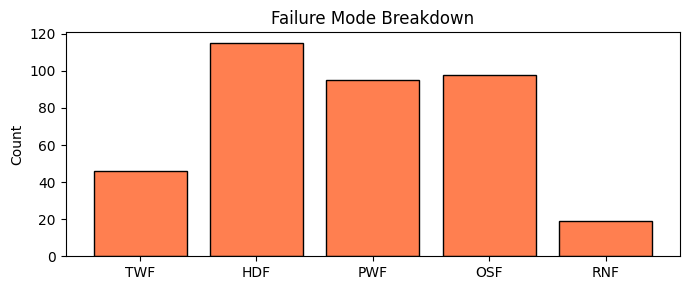

In [15]:
counts = {col: df[col].sum() for col in failure_cols}
plt.figure(figsize=(7, 3))
plt.bar(counts.keys(), counts.values(), color='coral', edgecolor='black')
plt.title('Failure Mode Breakdown')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Result

In [16]:
print("Inspection Summary")
print("-" * 40)
print(f"Rows              : {df.shape[0]}")
print(f"Columns           : {df.shape[1]}")
print(f"Missing Values    : {df.isnull().sum().sum()}")
print(f"Duplicate Rows    : {df.duplicated().sum()}")
print(f"Class Ratio (0:1) : {round(df['Machine failure'].value_counts()[0]/df['Machine failure'].value_counts()[1],1)} : 1")
print()
print("Observations:")
print("- No missing values or duplicates found")
print("- Severe class imbalance (28.5:1) - needs to be handled")
print("- UDI and Product ID are identifiers, not features")
print("- Torque and Tool wear show highest correlation with failure")
print("- Decision Tree handles outliers well, no removal needed")

Inspection Summary
----------------------------------------
Rows              : 10000
Columns           : 14
Missing Values    : 0
Duplicate Rows    : 0
Class Ratio (0:1) : 28.5 : 1

Observations:
- No missing values or duplicates found
- Severe class imbalance (28.5:1) - needs to be handled
- UDI and Product ID are identifiers, not features
- Torque and Tool wear show highest correlation with failure
- Decision Tree handles outliers well, no removal needed


**Conclusion:** The dataset was inspected for structure, missing values, duplicates, class distribution, outliers and correlations. The data is clean with no missing values but has a severe class imbalance of 28.5:1 which will be handled in the preprocessing step using SMOTE. These findings will guide the feature selection and preprocessing decisions.